# 1 — JUNO far reactors alone: the solar sector and the mass ordering

Two measurements are made here from JUNO's reactors alone, with no near source. "Far
reactors" means the nine reactors of the design report's Tab. 2 — the eight
Yangjiang/Taishan cores at $\approx52.5$ km **and** the effective Daya Bay core at $215$
km, which carries $\sim4\%$ of the flux but arrives six times less oscillated and so sets
the depth of the solar dip (notebook 3 §9). The fit to the real 59.1-day data uses the
repository's **standard method**, `reactor.nufit.standard_juno_fit()` — the NuFit
prescription validated against the official result in notebook 4:

1. **$\sin^2\theta_{12}$ and $\Delta m^2_{21}$**, taking the atmospheric sector
   ($\theta_{13}$, $\Delta m^2_{ee}$) from Daya Bay as an external prior. The pipeline is
   first validated against JUNO's published 59.1-day result, then projected to six years.
2. **The mass ordering** after six years, from the $\pm\Phi$ interference term in
   $P_{ee}$.

The relevant fact for the mass ordering is established in notebook 0: written in terms of
$\Delta m^2_{ee}$ the survival probability is

$$P_{ee}=1-\tfrac12\sin^2 2\theta_{13}\Big[1-\sqrt{1-\sin^2 2\theta_{12}\sin^2\Delta_{21}}\,
\cos(2|\Delta_{ee}|\pm\Phi)\Big]-\cos^4\theta_{13}\sin^2 2\theta_{12}\sin^2\Delta_{21},$$

and the **sign of $\Phi$ is the whole vacuum ordering signal**. It vanishes as
$\Delta_{21}\to0$, which is why a short-baseline source says nothing about the ordering.
(The expression printed in the draft, Eq. (A1), carries $+\Phi$ with no ordering sign.)

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt

from reactor import plotting as pl
from reactor.constants import *
from reactor.backgrounds import JUNO_BACKGROUND_RATES, JUNO_BACKGROUND_RATE_ERRORS
from reactor.detector import DetectorResponse, EnergyResolution
from reactor.experiment import *
from reactor.oscillations import survival_probability_ee
from reactor.statistics import *

pl.use_style()
YEAR = DAYS_PER_YEAR
truth = NUFIT61_NO

# Backgrounds: JUNO Yellow Book nominal rates for 20 kt.
BKG = dict(JUNO_BACKGROUND_RATES)
print("background rates [events/day]:", BKG, f"  total {sum(BKG.values()):.2f}/day")

edges = juno_reco_edges(bin_width_mev=0.02)      # 20 keV bins, 0.94-9.0 MeV
e_nu_grid = default_e_nu_grid(1600)
response = DetectorResponse(resolution=EnergyResolution())   # JUNO a/b/c
print(f"{edges.size-1} reconstructed bins over [{edges[0]:.2f}, {edges[-1]:.2f}] MeV")

def far_predictor(days, background_rates=BKG, resp=response, edges=edges):
    sample = juno_far_sample(days, background_rates=background_rates)
    return Predictor([sample], reco_edges_mev=edges, e_nu_grid_mev=e_nu_grid, response=resp)

background rates [events/day]: {'geoneutrino': 1.2, 'accidental': 0.8, 'li9he8': 0.8, 'fast_neutron': 0.1, 'alpha_n': 0.05, 'world_reactor': 1.0}   total 3.95/day
403 reconstructed bins over [0.94, 9.00] MeV


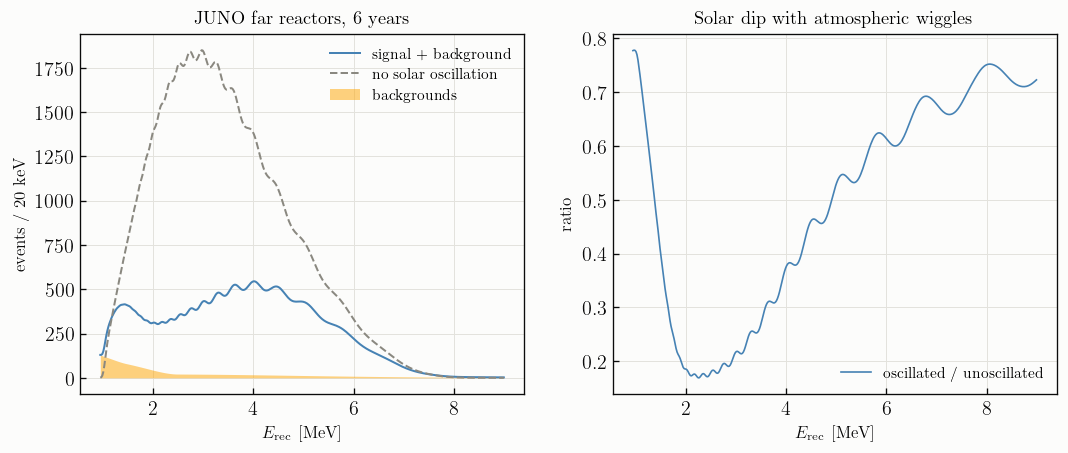

signal      : 98,933 events in 6 yr  (45.1/day)
backgrounds : 8,656 events        (3.9/day, 8.0% of the total)


In [2]:
# The far-reactor spectrum after six years.
P6 = far_predictor(6 * YEAR)
cen = P6.prompt_centers
sig6 = P6.counts(truth, include_backgrounds=False)[0]
bkg6 = P6.background_counts()[0]

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.9))
ax = axes[0]
ax.plot(cen, sig6 + bkg6, color=pl.BLUE, lw=1.2, label="signal + background")
ax.plot(cen, P6.counts(truth.replace(sin2_theta12=truth.sin2_theta12, dm2_21=0.0),
                       include_backgrounds=False)[0],
        color=pl.INK_MUTED, lw=1.2, ls="--", label=r"no solar oscillation")
ax.fill_between(cen, 0, bkg6, color=pl.ORANGE, alpha=0.5, lw=0, label="backgrounds")
ax.set_xlabel(r"$E_{\rm rec}$ [MeV]"); ax.set_ylabel("events / 20 keV")
ax.set_title("JUNO far reactors, 6 years"); ax.legend()

ax = axes[1]
ax.plot(cen, sig6 / P6.counts(truth, oscillate=False, include_backgrounds=False)[0],
        color=pl.BLUE, lw=1.0, label="oscillated / unoscillated")
ax.set_xlabel(r"$E_{\rm rec}$ [MeV]"); ax.set_ylabel("ratio")
ax.set_title("Solar dip with atmospheric wiggles"); ax.legend()
plt.show()

print(f"signal      : {sig6.sum():,.0f} events in 6 yr  ({sig6.sum()/(6*YEAR):.1f}/day)")
print(f"backgrounds : {bkg6.sum():,.0f} events        ({bkg6.sum()/(6*YEAR):.1f}/day, "
      f"{100*bkg6.sum()/(sig6.sum()+bkg6.sum()):.1f}% of the total)")

## 1. The measured spectrum

`reactor/data/JUNO_data_release_2025` is the data release accompanying
arXiv:2511.14593. It contains the 66-bin measured prompt-energy spectrum with every
background component, the collaboration's best fit, the measured energy resolution, the
fitted non-linearity curves, and the official $\Delta\chi^2$ surface.

The binning is non-uniform — 0.1 MeV through the bulk of the spectrum, widening to 2.6 MeV
in the last bin — and every column is stored as events per 0.1 MeV, so the loader rescales
by the bin width.

In [3]:
from reactor import juno_data as jd
from reactor.juno_fit import JUNO2025Model

spec = jd.load_spectrum()
print(f"live time {spec.livetime_days} d, {len(spec.centers)} bins over "
      f"{spec.edges[0]:.1f}-{spec.edges[-1]:.1f} MeV")
print(f"observed candidates : {spec.n_total:.0f}   (paper: {JUNO2025_CANDIDATES})")
print()
rows = [["best-fit signal", spec.pred_signal.sum(), spec.rate_per_day(spec.pred_signal), ""]]
for name, counts in spec.backgrounds.items():
    ref = JUNO2025_BACKGROUNDS_CPD.get(name)
    rows.append([name, counts.sum(), spec.rate_per_day(counts),
                 f"{ref[2]}" if ref else ""])
rows.append(["total background", spec.background_total.sum(),
             spec.rate_per_day(spec.background_total), ""])
print(pl.table(rows, ["component", "events", "cpd", "paper Table 1 [cpd]"],
               floatfmt="{:.2f}"))

live time 59.1 d, 66 bins over 0.7-12.0 MeV
observed candidates : 2379   (paper: 2379)

component         events   cpd    paper Table 1 [cpd]
-----------------------------------------------------
best-fit signal   2012.29  34.05                     
9Li/8He           227.42   3.85   3.9                
geoneutrino       81.01    1.37   1.4                
world reactors    51.88    0.88   0.88               
214Bi-214Po       11.97    0.20   0.2                
other             14.84    0.25                      
total background  387.12   6.55                      


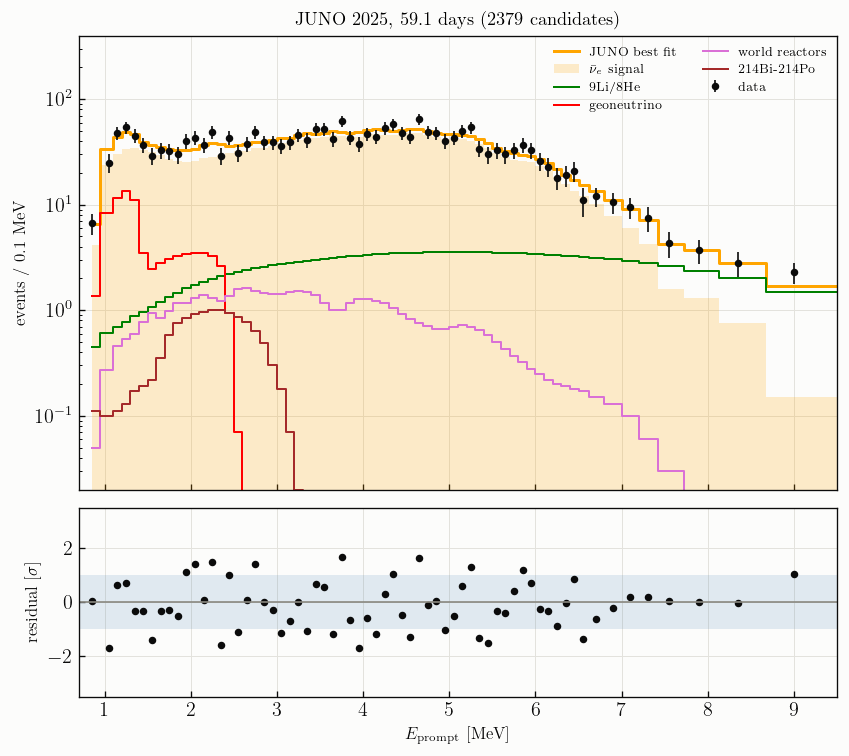

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(7.2, 6.4), sharex=True,
                         gridspec_kw={"height_ratios": [2.4, 1]})
ax = axes[0]
w = spec.widths
ax.errorbar(spec.centers, spec.n_obs / w * 0.1, yerr=spec.n_obs_err / w * 0.1,
            fmt="o", color=pl.INK, ms=3.5, lw=1.0, label="data", zorder=6)
ax.step(spec.centers, spec.pred_best_fit / w * 0.1, where="mid", color=pl.ORANGE,
        lw=1.8, label="JUNO best fit")
ax.fill_between(spec.centers, 0, spec.pred_signal / w * 0.1, step="mid",
                color=pl.ORANGE, alpha=0.20, lw=0, label=r"$\bar\nu_e$ signal")
for (name, counts), color in zip(spec.backgrounds.items(), pl.PALETTE[2:]):
    ax.step(spec.centers, counts / w * 0.1, where="mid", color=color, lw=1.2, label=name)
ax.set_yscale("log"); ax.set_ylim(0.02, 400)
ax.set_ylabel("events / 0.1 MeV")
ax.set_title(f"JUNO 2025, {spec.livetime_days} days ({spec.n_total:.0f} candidates)")
ax.legend(fontsize=7.5, ncol=2)

ax = axes[1]
e_r, w_r, resid = jd.load_residuals()
ax.axhspan(-1, 1, color=pl.BLUE, alpha=0.15, lw=0)
ax.plot(e_r, resid, "o", color=pl.INK, ms=3.5)
ax.axhline(0, color=pl.INK_MUTED, lw=1.0)
ax.set_ylim(-3.5, 3.5); ax.set_xlim(0.7, 9.5)
ax.set_xlabel(r"$E_{\rm prompt}$ [MeV]"); ax.set_ylabel(r"residual [$\sigma$]")
plt.tight_layout(); plt.show()

## 2. Fitting the data — the standard method

The fit below is `reactor.nufit.standard_juno_fit()`, the repository's standard method for
the 2025 release. It is NuFit's cnf 1 (Esteban *et al.*, arXiv:2601.09791v2), implemented
literally and validated against the official result in notebook 4:

* **Signal**: the nine reactors of the design report's Tab. 2 — eight Yangjiang/Taishan
  cores at $52.1$–$52.8$ km plus the effective Daya Bay core at $215$ km — weighted by
  $P_r/4\pi L_r^2$, with the Vogel–Beacom cross section. Daya Bay carries only $\sim4\%$ of
  the flux but lands on a solar *maximum* for the dip energies, so it sets the depth of the
  dip that $\theta_{12}$ is measured from (notebook 3 §9).
* **Flux**: the Daya Bay unfolded spectrum as a bin-average-conserving continuous shape
  (Huber $\times$ cardinal cubics), with the released $25\times25$ covariance carried as 25
  unit-Gaussian pulls.
* **Bin-per-bin rescaling** of the prediction to JUNO's own un-oscillated spectrum,
  recovered from the release as $({\rm data}-{\rm bkg})/P_{ee}^{\rm meas}$ — the decisive
  ingredient (notebook 4 §4): it removes the reactor-flux model from the analysis wherever
  the data can see it.
* **Nuisances**: normalisation $2.4\%$ — their Tab. 2 rate systematics ($1.8\%$) and the
  selection efficiency ($1.6\%$) in quadrature, the full documented budget that NuFit's
  note added restores; background priors $33/42/10/56/100\%$; the
  ${}^9$Li/${}^8$He shape pull ($20\%$ at 1 MeV, linear in energy); energy scale, bias and
  resolution pulls ($0.5/0.5/5\%$); the 25 flux pulls. CNP statistic, as JUNO use.
* **Atmospheric sector fixed externally**: $\sin^22\theta_{13}=0.0851$ and
  $\Delta m^2_{ee}=2.466\times10^{-3}$ eV$^2$ from Daya Bay; matter at $2.55$ g/cm$^3$.

Our own independent model (`JUNO2025Model`: Huber–Mueller or measured flux, anchored total
normalisation, no rescaling, six nuisances) is kept as a cross-check below.

In [5]:
from reactor.nufit import standard_juno_fit
from reactor.statistics import covariance_from_chi2_surface, correlation_from_covariance

model = standard_juno_fit()
fit = model.fit()

print(pl.table(
    [["sin^2(theta12)", fit["sin2_theta12"], JUNO2025_SIN2_THETA12, JUNO2025_SIN2_THETA12_ERR,
      (fit["sin2_theta12"]-JUNO2025_SIN2_THETA12)/JUNO2025_SIN2_THETA12_ERR],
     ["dm2_21 [1e-5 eV^2]", fit["dm2_21"]*1e5, JUNO2025_DM2_21*1e5, JUNO2025_DM2_21_ERR*1e5,
      (fit["dm2_21"]-JUNO2025_DM2_21)/JUNO2025_DM2_21_ERR]],
    ["parameter", "this work", "JUNO", "JUNO error", "offset [sigma]"], floatfmt="{:.4f}"))
print()
print(f"chi2 = {fit['chi2']:.1f} for {fit['n_bins']} bins at the external dm2_ee.")
print("(NuFit quote 49.4, but minimised over dm2_ee as well; freeing it reproduces their")
print(" Fig. 4 profile and closes most of the difference -- notebook 4 section 3.)")
print()
print(f"normalisation pull   : {fit['norm_pull']/model.config.sigma_norm:+.2f} sigma")
print("background pulls     : " + ", ".join(f"{k} {v:+.2f}" for k, v in fit["bkg_pulls"].items()))
print(f"9Li/8He shape pull   : {fit['lihe_shape_pull']:+.3f}  (prior 0.20)")
print(f"energy pulls         : " + ", ".join(f"{k} {v:+.4f}" for k, v in fit["energy_pulls"].items()))
print(f"flux pulls rms       : {fit['flux_pulls_rms']:.2f}  (25 unit-Gaussian pulls)")
print()
print("Every nuisance sits well inside its prior: the standard method needs no tuning to")
print("land on JUNO's best fit.")

parameter           this work  JUNO    JUNO error  offset [sigma]
-----------------------------------------------------------------
sin^2(theta12)      0.3087     0.3092  0.0087      -0.0603       
dm2_21 [1e-5 eV^2]  7.4826     7.5000  0.1200      -0.1450       

chi2 = 55.8 for 66 bins at the external dm2_ee.
(NuFit quote 49.4, but minimised over dm2_ee as well; freeing it reproduces their
 Fig. 4 profile and closes most of the difference -- notebook 4 section 3.)

normalisation pull   : -0.57 sigma
background pulls     : 9Li/8He -0.01, geoneutrino +0.06, world reactors -0.00, 214Bi-214Po +0.14, other +0.23
9Li/8He shape pull   : -0.006  (prior 0.20)
energy pulls         : scale +0.0009, bias +0.0009, resolution +0.0032
flux pulls rms       : 0.13  (25 unit-Gaussian pulls)

Every nuisance sits well inside its prior: the standard method needs no tuning to
land on JUNO's best fit.


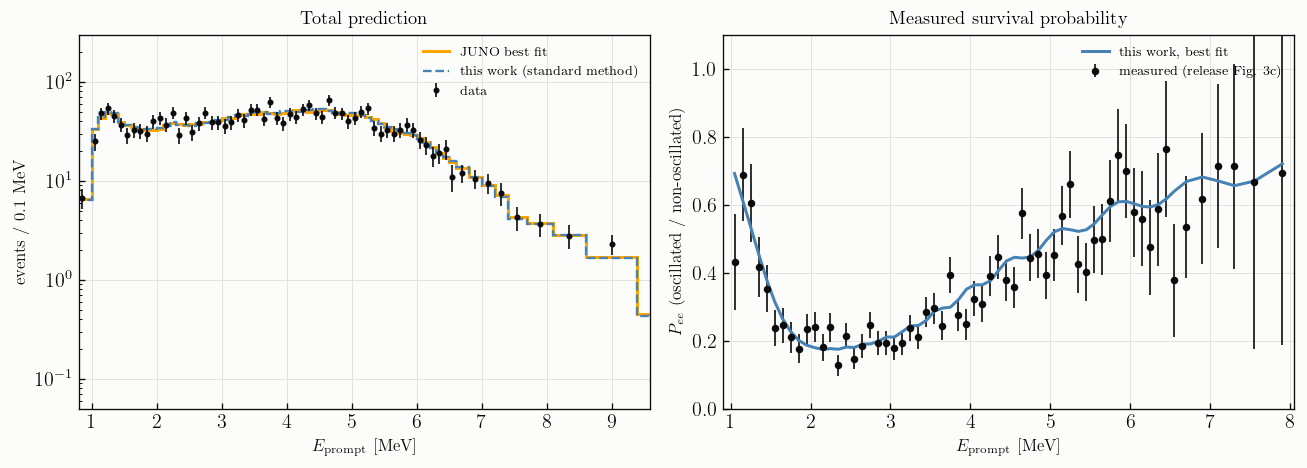

In [6]:
# Prediction against the data, and the measured survival probability (their Fig. 3c).
n_bkg = len(model._bkg_names)
chi2_val, pulls = model.profiled_chi2(fit["sin2_theta12"], fit["dm2_21"])
base, cols = model._basis(fit["sin2_theta12"], fit["dm2_21"])
pred = (1 + pulls[0])*(base + pulls[2+n_bkg:] @ cols) \
     + model.background(pulls[1:1+n_bkg], pulls[1+n_bkg])

e_c, w_c, pee_meas, pee_err = jd.load_survival_probability()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))
ax = axes[0]
ax.stairs(spec.pred_best_fit/spec.widths*0.1, spec.edges, color=pl.ORANGE, lw=1.8,
          label="JUNO best fit")
ax.stairs(pred/spec.widths*0.1, spec.edges, color=pl.BLUE, lw=1.4, ls="--",
          label="this work (standard method)")
ax.errorbar(spec.centers, spec.n_obs/spec.widths*0.1,
            yerr=spec.n_obs_err/spec.widths*0.1, fmt="o", ms=2.6, color=pl.INK,
            lw=1.0, label="data")
ax.set_yscale("log"); ax.set_xlim(0.8, 9.6); ax.set_ylim(0.05, 3e2)
ax.set_xlabel(r"$E_{\rm prompt}$ [MeV]"); ax.set_ylabel("events / 0.1 MeV")
ax.legend(fontsize=8); ax.set_title("Total prediction")

ax = axes[1]
sel = (e_c > 0.9) & (e_c < 8.05)
ax.errorbar(e_c[sel], pee_meas[sel], yerr=pee_err[sel], fmt="o", color=pl.INK, ms=3.5,
            lw=1.0, label="measured (release Fig. 3c)")
ratio_model = model.signal(fit["sin2_theta12"], fit["dm2_21"]) / model.unoscillated()
ax.plot(spec.centers[sel], ratio_model[sel], color=pl.BLUE, lw=1.8,
        label="this work, best fit")
ax.set_xlim(0.9, 8.05); ax.set_ylim(0, 1.1)
ax.set_xlabel(r"$E_{\rm prompt}$ [MeV]")
ax.set_ylabel(r"$P_{ee}$ (oscillated / non-oscillated)")
ax.legend(fontsize=8); ax.set_title("Measured survival probability")
plt.tight_layout(); plt.show()

### Comparison with the official $\Delta\chi^2$ surface

The release includes JUNO's own $\Delta\chi^2$ map (their Fig. 4), which
supersedes any digitized contour and lets us compare confidence regions directly rather
than only best-fit points.

(191 s)
analysis                 sigma(sin^2 th12)  sigma(dm2_21) [1e-5]  rho     
--------------------------------------------------------------------------
JUNO official map        0.00877            0.11787               -0.22416
standard method          0.00846            0.11807               -0.27256
independent cross-check  0.00779            0.11071               -0.32339


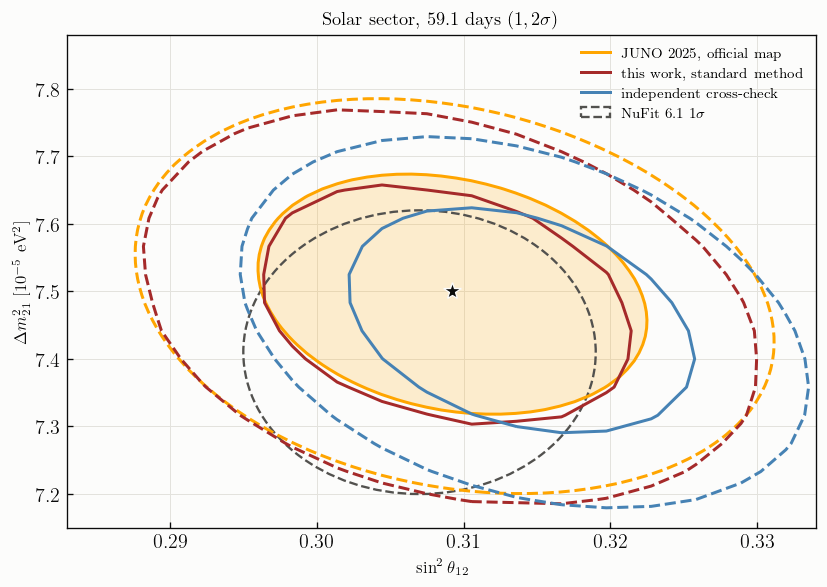

In [7]:
s12_off, dm2_off, chi2_off = jd.load_chi2_map()
cov_off = covariance_from_chi2_surface(s12_off, dm2_off, chi2_off - chi2_off.min())
cov_nufit = np.diag([NUFIT61_NO_ERRORS["sin2_theta12"]**2, (NUFIT61_NO_ERRORS["dm2_21"]*1e5)**2])

t0 = time.time()
s12_g = np.linspace(0.280, 0.335, 19)
dm2_g = np.linspace(7.15, 7.90, 19)*1e-5
g_std = model.scan(s12_g, dm2_g); g_std -= g_std.min()
g_own = JUNO2025Model().scan(s12_g, dm2_g, profile=True); g_own -= g_own.min()
print(f"({time.time()-t0:.0f} s)")

rows = [["JUNO official map", np.sqrt(cov_off[0, 0]), np.sqrt(cov_off[1, 1]),
         correlation_from_covariance(cov_off)]]
for lab, g in [("standard method", g_std), ("independent cross-check", g_own)]:
    C = covariance_from_chi2_surface(s12_g, dm2_g*1e5, g)
    rows.append([lab, np.sqrt(C[0, 0]), np.sqrt(C[1, 1]), correlation_from_covariance(C)])
print(pl.table(rows, ["analysis", "sigma(sin^2 th12)", "sigma(dm2_21) [1e-5]", "rho"],
               floatfmt="{:.5f}"))

fig, ax = plt.subplots(figsize=(7.0, 5.0))
pl.confidence_contours(ax, s12_off, dm2_off, chi2_off - chi2_off.min(),
                       color=pl.ORANGE, label="JUNO 2025, official map",
                       levels=pl.DELTA_CHI2_2DOF[:2])
pl.confidence_contours(ax, s12_g, dm2_g*1e5, g_std, color=pl.BROWN,
                       label="this work, standard method", fill=False,
                       levels=pl.DELTA_CHI2_2DOF[:2])
pl.confidence_contours(ax, s12_g, dm2_g*1e5, g_own, color=pl.BLUE,
                       label="independent cross-check", fill=False,
                       levels=pl.DELTA_CHI2_2DOF[:2])
pl.error_ellipse(ax, (truth.sin2_theta12, truth.dm2_21*1e5), cov_nufit,
                 color=pl.INK_SECONDARY, lw=1.4, ls="--", label=r"NuFit 6.1 $1\sigma$")
pl.mark_best_fit(ax, JUNO2025_SIN2_THETA12, JUNO2025_DM2_21*1e5)
ax.set_xlim(0.283, 0.334); ax.set_ylim(7.15, 7.88)
ax.set_xlabel(r"$\sin^2\theta_{12}$"); ax.set_ylabel(r"$\Delta m^2_{21}$ [$10^{-5}$ eV$^2$]")
ax.set_title(r"Solar sector, 59.1 days ($1,2\sigma$)")
ax.legend(fontsize=8.5, loc="upper right")
plt.tight_layout(); plt.show()

### What it took to get here

The standard method was not the starting point. The path to it is documented in notebooks 3
and 4; the table records the findings so this notebook stays self-contained.

| finding | effect on $\sin^2\theta_{12}$ | where shown |
|---|---|---|
| the Daya Bay complex belongs in the signal (it sits on a solar *maximum* for the dip energies) | omitting it: $1.39\sigma$ in 2D, $+5$ units of $\chi^2$ | nb 3 §9 |
| the prediction must be rescaled bin-per-bin to JUNO's own un-oscillated spectrum | without it: $0.34\sigma$ away instead of $0.10\sigma$ (cnf 1 numbers) | nb 4 §4 |
| once rescaled, the flux model is a null | Appendix-A vs centre-interp vs Huber–Mueller: $\lesssim0.0004$ | nb 4 §4 |
| cross section, flux pulls, background priors, resolution form | $\lesssim0.002$ altogether | nb 4 §4 |
| Fangchenggang: signal or background is a convention | null if consistent; $+0.002$ if double-counted | nb 3 §9.4 |
| NuFit's quoted $\chi^2_{\rm min}\approx49$ is a 3-parameter minimum | freeing $\Delta m^2_{ee}$: $55.9\to52.0$ at their $2.80\times10^{-3}$ | nb 4 §3 |

One residual is common to both our implementations and worth keeping visible: the region's
tilt. The official map has $\rho=-0.22$; the standard method and the cross-check both give
$\rho\approx-0.31$. The one quantitative handle we have is the overall rate freedom:

In [8]:
# The residual tilt: how the region's shape responds to the rate freedom, probed with the
# cross-check model (single normalisation nuisance, so the effect is isolated).
def surface_shape(m, n=17):
    s12 = np.linspace(0.28, 0.34, n); dm2 = np.linspace(7.15, 7.90, n)*1e-5
    g = m.scan(s12, dm2, profile=True); g -= g.min()
    C = covariance_from_chi2_surface(s12, dm2*1e5, g)
    return np.sqrt(C[0, 0]), np.sqrt(C[1, 1]), correlation_from_covariance(C)

rows = [["JUNO official map", np.sqrt(cov_off[0, 0]), np.sqrt(cov_off[1, 1]),
         correlation_from_covariance(cov_off)]]
t0 = time.time()
for label, prior in [("2.4% (Table 2 + efficiency)", 0.024), ("4%", 0.04), ("6%", 0.06)]:
    rows.append([f"cross-check, rate {label}", *surface_shape(JUNO2025Model(rate_prior=prior))])
print(pl.table(rows, ["rate freedom", "sigma(sin^2 th12)", "sigma(dm2_21) [1e-5]", "rho"],
               floatfmt="{:.5f}"))
print(f"({time.time()-t0:.0f} s)")
print()
print("About 4% of rate freedom reproduces the official width and tilt together in this")
print("cross-check model; the standard method, tested next, wants about 3%. Neither")
print("our 2.4% (Table 2 + efficiency) nor NuFit's 1.8% grants that much, which is why both")
print("reimplementations end up slightly tighter and more steeply tilted than the official")
print("region: JUNO's own fit carries ~30 Daya-Bay-constrained spectral coefficients whose")
print("collective rate freedom neither pull set fully mimics. This is a second-order effect")
print("on the ellipse and does not move the best fit.")

rate freedom                                   sigma(sin^2 th12)  sigma(dm2_21) [1e-5]  rho     
------------------------------------------------------------------------------------------------
JUNO official map                              0.00877            0.11787               -0.22416
cross-check, rate 2.4% (Table 2 + efficiency)  0.00782            0.11080               -0.32411
cross-check, rate 4%                           0.00858            0.11445               -0.20256
cross-check, rate 6%                           0.00932            0.11766               -0.10653
(31 s)

About 4% of rate freedom reproduces the official width and tilt together in this
cross-check model; the standard method, tested next, wants about 3%. Neither
our 2.4% (Table 2 + efficiency) nor NuFit's 1.8% grants that much, which is why both
reimplementations end up slightly tighter and more steeply tilted than the official
region: JUNO's own fit carries ~30 Daya-Bay-constrained spectral coefficients whose

### The ellipse with more rate freedom

Where could extra effective freedom live? Our $2.4\%$ counts their Tab. 2 rate systematics
($1.8\%$) and the selection efficiency ($1.6\%$). The segment test in notebook 4 and the
scans above constrain the missing piece's character: *shape* nuisances do not rotate
$\rho$, so whatever JUNO has that the reimplementations lack must be **coherent in
energy** — rate-like. Candidates not in either pull set:

* the **delivered-power history** of an outage-dominated 59 days — YJ1 and YJ4 off for parts
  of the run, a typhoon power reduction (their Fig. 10) — which JUNO model in time and we
  compress into one anchored number;
* the **absolute-rate anchor of the Daya-Bay extrapolation**: the released flux covariance is
  only $1.35\%$ coherent, but JUNO's internal extrapolation uncertainty need not be so tight;
* the **target-proton number** ($\sim0.9\%$) if it sits outside the Tab. 2 quadrature;
* the **off-equilibrium and spent-fuel corrections**, each a percent-level correction known
  to a few tens of percent.

Below, the standard method is granted $\sigma_{\rm norm}=3\%$ and $4\%$ and refit. The
answer turns out to be milder than the cross-check model's $4\%$: the official ellipse is
reproduced at $\approx3\%$, i.e. only $\sqrt{3^2-2.4^2}\approx1.8\%$ in quadrature beyond
the documented budget — the size of the Daya Bay absolute anchor alone. (That the two
parameterisations want different values is itself the reminder that this is the *effective*
freedom of a one-parameter proxy for JUNO's $\sim30$ spectral coefficients, not a literal
budget line.)

(473 s)
analysis                     sin^2(th12)  sigma(s12^2)  sigma(dm2_21)  rho     
-------------------------------------------------------------------------------
JUNO official map            nan          0.00877       0.11787        -0.22416
standard, sigma_norm = 2.4%  0.30867      0.00846       0.11807        -0.27256
standard, sigma_norm = 3%    0.30781      0.00880       0.11977        -0.23048
standard, sigma_norm = 4%    0.30652      0.00934       0.12269        -0.16894

3% reproduces the official width and tilt together (0.00880/-0.230 vs 0.00877/-0.224);
4% overshoots both. The extra freedom carries a small price at the best-fit point --
the freer normalisation lets sin^2(theta12) drift down to 0.3078 (-0.16 sigma) -- so
the standard method keeps the documented 2.4%: an honest prior beats a tuned one, and
all of these variants are statistically indistinguishable.


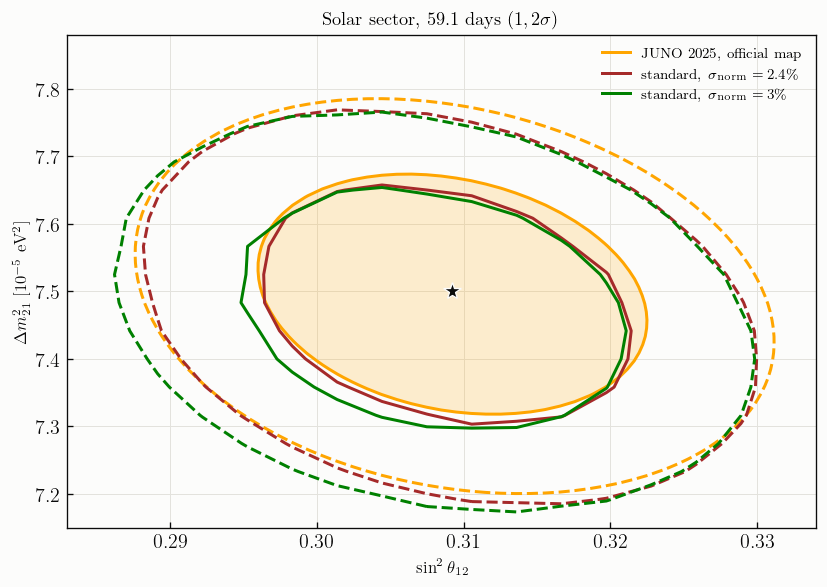

In [9]:
import dataclasses as _dc

t0 = time.time()
scans = {}
fits4 = {}
for sn in (0.03, 0.04):
    cfg = _dc.replace(model.config, name=f"cnf 1, {100*sn:.0f}% norm", sigma_norm=sn)
    mm = standard_juno_fit(config=cfg)
    fits4[sn] = mm.fit()
    gg = mm.scan(s12_g, dm2_g)
    scans[sn] = gg - gg.min()
print(f"({time.time()-t0:.0f} s)")

C18 = covariance_from_chi2_surface(s12_g, dm2_g*1e5, g_std)
rows = [["JUNO official map", np.nan, np.sqrt(cov_off[0, 0]), np.sqrt(cov_off[1, 1]),
         correlation_from_covariance(cov_off)],
        [f"standard, sigma_norm = {100*model.config.sigma_norm:.1f}%", fit["sin2_theta12"],
         np.sqrt(C18[0, 0]), np.sqrt(C18[1, 1]), correlation_from_covariance(C18)]]
for sn in (0.03, 0.04):
    C = covariance_from_chi2_surface(s12_g, dm2_g*1e5, scans[sn])
    rows.append([f"standard, sigma_norm = {100*sn:.0f}%", fits4[sn]["sin2_theta12"],
                 np.sqrt(C[0, 0]), np.sqrt(C[1, 1]), correlation_from_covariance(C)])
print(pl.table(rows, ["analysis", "sin^2(th12)", "sigma(s12^2)", "sigma(dm2_21)", "rho"],
               floatfmt="{:.5f}"))
print()
print("3% reproduces the official width and tilt together (0.00880/-0.230 vs 0.00877/-0.224);")
print("4% overshoots both. The extra freedom carries a small price at the best-fit point --")
print("the freer normalisation lets sin^2(theta12) drift down to 0.3078 (-0.16 sigma) -- so")
print("the standard method keeps the documented 2.4%: an honest prior beats a tuned one, and")
print("all of these variants are statistically indistinguishable.")

fig, ax = plt.subplots(figsize=(7.0, 5.0))
pl.confidence_contours(ax, s12_off, dm2_off, chi2_off - chi2_off.min(),
                       color=pl.ORANGE, label="JUNO 2025, official map",
                       levels=pl.DELTA_CHI2_2DOF[:2])
pl.confidence_contours(ax, s12_g, dm2_g*1e5, g_std, color=pl.BROWN,
                       label=r"standard, $\sigma_{\rm norm}=2.4\%$", fill=False,
                       levels=pl.DELTA_CHI2_2DOF[:2])
pl.confidence_contours(ax, s12_g, dm2_g*1e5, scans[0.03], color=pl.GREEN,
                       label=r"standard, $\sigma_{\rm norm}=3\%$", fill=False,
                       levels=pl.DELTA_CHI2_2DOF[:2])
pl.mark_best_fit(ax, JUNO2025_SIN2_THETA12, JUNO2025_DM2_21*1e5)
ax.set_xlim(0.283, 0.334); ax.set_ylim(7.15, 7.88)
ax.set_xlabel(r"$\sin^2\theta_{12}$"); ax.set_ylabel(r"$\Delta m^2_{21}$ [$10^{-5}$ eV$^2$]")
ax.set_title(r"Solar sector, 59.1 days ($1,2\sigma$)")
ax.legend(fontsize=8.5, loc="upper right")
plt.tight_layout(); plt.show()

### Summary of the comparison

The standard method lands on JUNO's best fit ($0.06\sigma$ in $\sin^2\theta_{12}$,
$0.18\sigma$ in 2D) with every nuisance inside its prior and nothing tuned; the region's
widths agree to $3.5\%$ and $0.2\%$ and the residual tilt difference ($\rho=-0.27$ vs
$-0.22$) is
understood in direction and size — granting the standard method $\approx3\%$ of effective rate freedom — only
$\approx1.8\%$ in quadrature beyond the documented budget — reproduces the official
ellipse's width and tilt together, as shown above. The frequency parameter remains the robust one —
$\sigma(\Delta m^2_{21})$ agrees with the official surface at the percent level under every
variation tried here and in notebooks 3–4.

## 3. Six-year solar-sector sensitivity

Now with the full background set, the canonical systematic budget, and Daya Bay's
constraints on the atmospheric sector. JUNO's own design targets are
$\sigma(\sin^2\theta_{12})/\sin^2\theta_{12}\approx0.5\%$ and
$\sigma(\Delta m^2_{21})/\Delta m^2_{21}\approx0.3\%$ after six years.

In [10]:
syst_far = Systematics(sigma_flux=0.02, sigma_xsec=0.03, sigma_eff=0.01,
                       sigma_shape=0.01, shape_lambda_mev=0.7,
                       sigma_eres=0.035, sigma_bkg=0.20)

PARS = ["sin2_theta12", "dm2_21", "sin2_theta13", "dm2_ee"]
rows = []
for years in [0.5, 1.0, 2.0, 4.0, 6.0, 10.0]:
    A = Analysis(far_predictor(years * YEAR), truth, systematics=syst_far,
                 priors=dayabay_priors())
    err = A.fisher_errors(PARS)
    rows.append([years,
                 err["sin2_theta12"], 100*err["sin2_theta12"]/truth.sin2_theta12,
                 err["dm2_21"]*1e5, 100*err["dm2_21"]/truth.dm2_21,
                 err["dm2_ee"]*1e3, 100*err["dm2_ee"]/truth.dm2_ee])
print(pl.table(rows, ["years", "sig(s12^2)", "[%]", "sig(dm21) 1e-5", "[%]",
                      "sig(dm2ee) 1e-3", "[%]"], floatfmt="{:.4f}"))

A6 = Analysis(far_predictor(6 * YEAR), truth, systematics=syst_far, priors=dayabay_priors())
err6 = A6.fisher_errors(PARS)
print()
print(f"6 years:  sigma(sin^2 th12)/sin^2 th12 = {100*err6['sin2_theta12']/truth.sin2_theta12:.2f}%"
      f"   (JUNO target ~0.5%)")
print(f"          sigma(dm2_21)/dm2_21         = {100*err6['dm2_21']/truth.dm2_21:.2f}%"
      f"   (JUNO target ~0.3%)")
print(f"          sigma(dm2_ee)/dm2_ee         = {100*err6['dm2_ee']/truth.dm2_ee:.2f}%"
      f"   (JUNO target ~0.2%)")

years    sig(s12^2)  [%]     sig(dm21) 1e-5  [%]     sig(dm2ee) 1e-3  [%]   
----------------------------------------------------------------------------
0.5000   0.0046      1.5070  0.0537          0.7241  0.0149           0.5968
1.0000   0.0035      1.1561  0.0405          0.5460  0.0107           0.4292
2.0000   0.0028      0.9056  0.0309          0.4175  0.0077           0.3067
4.0000   0.0023      0.7357  0.0243          0.3284  0.0055           0.2189
6.0000   0.0020      0.6653  0.0216          0.2909  0.0045           0.1799
10.0000  0.0018      0.5996  0.0189          0.2557  0.0035           0.1409

6 years:  sigma(sin^2 th12)/sin^2 th12 = 0.67%   (JUNO target ~0.5%)
          sigma(dm2_21)/dm2_21         = 0.29%   (JUNO target ~0.3%)
          sigma(dm2_ee)/dm2_ee         = 0.18%   (JUNO target ~0.2%)


In [11]:
# Where does the solar-sector precision come from, and what limits it?
variants = {
    "canonical": syst_far,
    "statistics only": Systematics.statistics_only(),
    "no shape term": syst_far.without("shape"),
    "no normalisation": syst_far.without("norm"),
    "no energy resolution": syst_far.without("eres"),
    "shape 6% (validation)": Systematics(**{**syst_far.__dict__, "sigma_shape": 0.06}),
}
rows = []
for name, syst in variants.items():
    A = Analysis(far_predictor(6 * YEAR), truth, systematics=syst, priors=dayabay_priors())
    e = A.fisher_errors(PARS)
    rows.append([name, e["sin2_theta12"], e["dm2_21"]*1e5, e["dm2_ee"]*1e3])
print(pl.table(rows, ["6 yr, far only", "sig(sin^2 th12)", "sig(dm21) 1e-5", "sig(dm2ee) 1e-3"],
               floatfmt="{:.4f}"))

6 yr, far only         sig(sin^2 th12)  sig(dm21) 1e-5  sig(dm2ee) 1e-3
-----------------------------------------------------------------------
canonical              0.0020           0.0216          0.0045         
statistics only        0.0009           0.0128          0.0044         
no shape term          0.0014           0.0160          0.0044         
no normalisation       0.0015           0.0208          0.0045         
no energy resolution   0.0020           0.0215          0.0045         
shape 6% (validation)  0.0077           0.0820          0.0061         


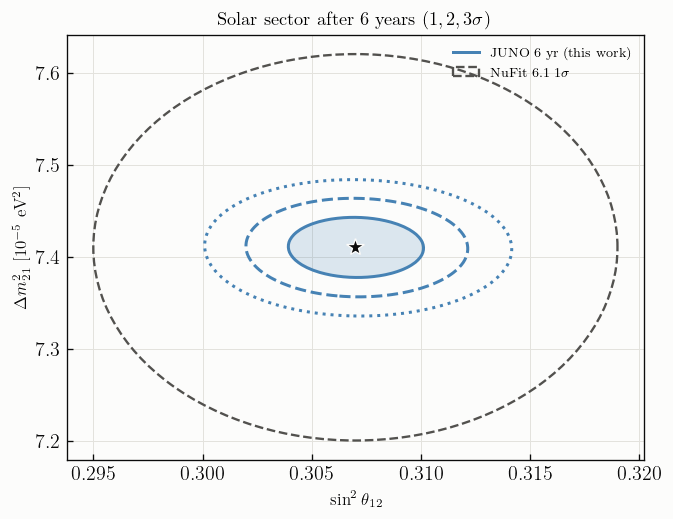

In [12]:
# Six-year contour in the solar plane.
s12_g = np.linspace(0.296, 0.318, 81)
dm21_g = np.linspace(7.30e-5, 7.52e-5, 81)
chi2_6 = A6.grid("sin2_theta12", s12_g, "dm2_21", dm21_g)

fig, ax = plt.subplots(figsize=(6.2, 4.6))
pl.confidence_contours(ax, s12_g, dm21_g*1e5, chi2_6, color=pl.BLUE, label="JUNO 6 yr (this work)")
pl.mark_best_fit(ax, truth.sin2_theta12, truth.dm2_21*1e5)
pl.error_ellipse(ax, (truth.sin2_theta12, truth.dm2_21*1e5), cov_nufit,
                 color=pl.INK_SECONDARY, lw=1.4, ls="--", label=r"NuFit 6.1 $1\sigma$")
ax.set_xlabel(r"$\sin^2\theta_{12}$"); ax.set_ylabel(r"$\Delta m^2_{21}$ [$10^{-5}$ eV$^2$]")
ax.set_title(r"Solar sector after 6 years ($1,2,3\sigma$)")
ax.legend(loc="upper right", fontsize=8)
plt.show()

## 4. Mass ordering

The ordering flips the sign of $\Phi$, which shifts the phase of the fast atmospheric
wiggle by an amount that grows with $\Delta_{21}$ and therefore with energy. A wrong-ordering
fit can partly absorb this by shifting $|\Delta m^2_{ee}|$, so the fit below leaves
$|\Delta m^2_{ee}|$, $\theta_{13}$, $\theta_{12}$ and $\Delta m^2_{21}$ free.

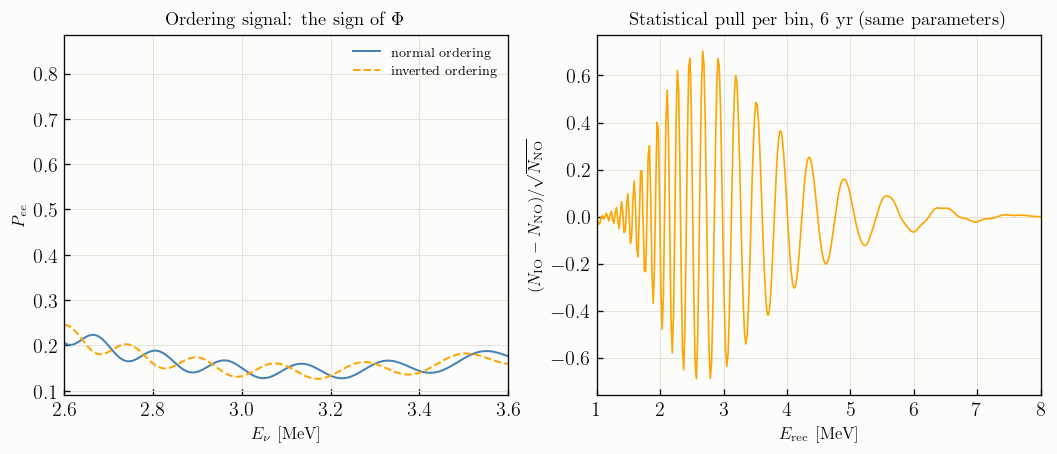

max |P_NO - P_IO|                        : 0.0744
naive bin-summed significance (no refit) : 4.4 sigma
The refit below is much less optimistic because |dm2_ee| absorbs most of the shift.


In [13]:
io_truth = truth.replace(ordering=-1)
E = np.linspace(1.81, 9.0, 6000)
p_no = survival_probability_ee(E, 52.5, truth)
p_io = survival_probability_ee(E, 52.5, io_truth)

P6b = far_predictor(6 * YEAR)
c_no = P6b.counts(truth)[0]
c_io = P6b.counts(io_truth)[0]

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.9))
ax = axes[0]
ax.plot(E, p_no, color=pl.BLUE, lw=1.2, label="normal ordering")
ax.plot(E, p_io, color=pl.ORANGE, lw=1.2, ls="--", label="inverted ordering")
ax.set_xlim(2.6, 3.6); ax.set_xlabel(r"$E_\nu$ [MeV]"); ax.set_ylabel(r"$P_{ee}$")
ax.set_title(r"Ordering signal: the sign of $\Phi$"); ax.legend(fontsize=8)

ax = axes[1]
ax.plot(cen, (c_io - c_no) / np.sqrt(np.maximum(c_no, 1)), color=pl.ORANGE, lw=1.0)
ax.set_xlim(1.0, 8.0)
ax.set_xlabel(r"$E_{\rm rec}$ [MeV]"); ax.set_ylabel(r"$(N_{\rm IO}-N_{\rm NO})/\sqrt{N_{\rm NO}}$")
ax.set_title("Statistical pull per bin, 6 yr (same parameters)")
plt.show()

print(f"max |P_NO - P_IO|                        : {np.max(np.abs(p_no-p_io)):.4f}")
print(f"naive bin-summed significance (no refit) : {np.sqrt(np.sum((c_io-c_no)**2/np.maximum(c_no,1))):.1f} sigma")
print("The refit below is much less optimistic because |dm2_ee| absorbs most of the shift.")

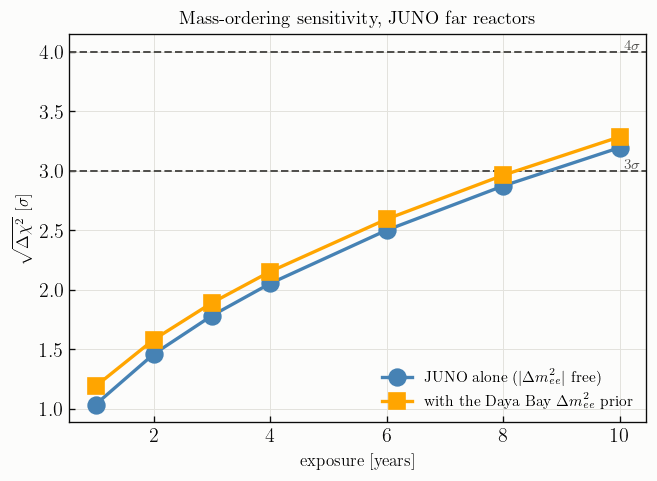

6 years, JUNO alone            : Delta chi^2 = 6.3  (2.50 sigma)
6 years, + Daya Bay dm2_ee     : Delta chi^2 = 6.7  (2.59 sigma)

A word on the exposure convention. JUNO's often-quoted '3 sigma in 6 years' assumed
35.8 GW of reactor power; the Taishan 3/4 cores were cancelled, so the real complex is
26.6 GW and the equivalent exposure is ~8 years (arXiv:2107.12410, footnote 1).
JUNO also counts a 'year' as ~300 days of live time, i.e. 8 yr = 2400 live days.
Our years are calendar years with an 11/12 reactor duty cycle, so
  6 of our years = 2009 full-power days = 6.7 JUNO years.
Section 4 repeats the calculation in their conventions.


In [14]:
# Asimov Delta chi^2 between the wrong and the true ordering, vs exposure.
FREE_MO = ["dm2_ee", "sin2_theta13", "sin2_theta12", "dm2_21"]

def mo_delta_chi2(years, systematics, priors=(), matter=False, free=FREE_MO):
    A = Analysis(far_predictor(years * YEAR), truth, systematics=systematics,
                 priors=priors, matter=matter)
    chi2_true, _ = A.minimize(free)
    wrong = truth.replace(ordering=-1)
    chi2_wrong, best = A.minimize(free, start=wrong, fixed={"ordering": -1})
    return chi2_wrong - chi2_true, best

years_grid = np.array([1.0, 2.0, 3.0, 4.0, 6.0, 8.0, 10.0])
dchi2_free, dchi2_prior = [], []
for y in years_grid:
    d1, _ = mo_delta_chi2(y, syst_far)
    d2, _ = mo_delta_chi2(y, syst_far, priors=dayabay_priors())
    dchi2_free.append(d1); dchi2_prior.append(d2)
dchi2_free = np.array(dchi2_free); dchi2_prior = np.array(dchi2_prior)

fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.plot(years_grid, np.sqrt(np.maximum(dchi2_free, 0)), color=pl.BLUE, marker="o",
        label=r"JUNO alone ($|\Delta m^2_{ee}|$ free)")
ax.plot(years_grid, np.sqrt(np.maximum(dchi2_prior, 0)), color=pl.ORANGE, marker="s",
        label="with the Daya Bay $\\Delta m^2_{ee}$ prior")
for lvl, lab in [(3.0, r"$3\sigma$"), (4.0, r"$4\sigma$")]:
    pl.hline_reference(ax, lvl, lab)
ax.set_xlabel("exposure [years]"); ax.set_ylabel(r"$\sqrt{\Delta\chi^2}$  [$\sigma$]")
ax.set_title("Mass-ordering sensitivity, JUNO far reactors")
ax.legend(loc="lower right")
plt.show()

i6 = int(np.where(years_grid == 6.0)[0][0])
print(f"6 years, JUNO alone            : Delta chi^2 = {dchi2_free[i6]:.1f}  "
      f"({np.sqrt(dchi2_free[i6]):.2f} sigma)")
print(f"6 years, + Daya Bay dm2_ee     : Delta chi^2 = {dchi2_prior[i6]:.1f}  "
      f"({np.sqrt(dchi2_prior[i6]):.2f} sigma)")
print()
print("A word on the exposure convention. JUNO's often-quoted '3 sigma in 6 years' assumed")
print("35.8 GW of reactor power; the Taishan 3/4 cores were cancelled, so the real complex is")
print("26.6 GW and the equivalent exposure is ~8 years (arXiv:2107.12410, footnote 1).")
print("JUNO also counts a 'year' as ~300 days of live time, i.e. 8 yr = 2400 live days.")
print("Our years are calendar years with an 11/12 reactor duty cycle, so")
print(f"  {6:.0f} of our years = {6*YEAR*11/12:.0f} full-power days = {6*YEAR*11/12/300:.1f} JUNO years.")
print("Section 4 repeats the calculation in their conventions.")

In [15]:
# What the wrong-ordering fit does to |dm2_ee|, and what drives the sensitivity.
d6, best_io = mo_delta_chi2(6.0, syst_far)
print("Best-fit parameters in the wrong (inverted) ordering, 6 yr:")
print(f"  |dm2_ee|      = {abs(best_io['dm2_ee']):.5e} eV^2   "
      f"(truth {truth.dm2_ee:.5e}, shift {1e5*(abs(best_io['dm2_ee'])-truth.dm2_ee):+.2f}e-5)")
print(f"  sin^2 th13    = {best_io['sin2_theta13']:.5f}  (truth {truth.sin2_theta13:.5f})")
print(f"  sin^2 th12    = {best_io['sin2_theta12']:.5f}  (truth {truth.sin2_theta12:.5f})")
print(f"  dm2_21        = {best_io['dm2_21']:.4e}   (truth {truth.dm2_21:.4e})")
print()

rows = []
for name, kwargs in [
    ("canonical", dict(systematics=syst_far)),
    ("statistics only", dict(systematics=Systematics.statistics_only())),
    ("no shape term", dict(systematics=syst_far.without("shape"))),
    ("no energy-resolution term", dict(systematics=syst_far.without("eres"))),
    ("+ Daya Bay dm2_ee prior", dict(systematics=syst_far, priors=dayabay_priors())),
    ("with matter effects", dict(systematics=syst_far, matter=True)),
]:
    d, _ = mo_delta_chi2(6.0, **kwargs)
    rows.append([name, d, np.sqrt(max(d, 0))])
print(pl.table(rows, ["6 yr configuration", "Delta chi^2", "significance [sigma]"],
               floatfmt="{:.2f}"))

Best-fit parameters in the wrong (inverted) ordering, 6 yr:
  |dm2_ee|      = 2.51075e-03 eV^2   (truth 2.49400e-03, shift +1.68e-5)
  sin^2 th13    = 0.02060  (truth 0.02215)
  sin^2 th12    = 0.30707  (truth 0.30700)
  dm2_21        = 7.4097e-05   (truth 7.4100e-05)



6 yr configuration         Delta chi^2  significance [sigma]
------------------------------------------------------------
canonical                  6.26         2.50                
statistics only            6.57         2.56                
no shape term              6.37         2.52                
no energy-resolution term  6.35         2.52                
+ Daya Bay dm2_ee prior    6.73         2.59                
with matter effects        5.89         2.43                


a [%]  sigma_E/E at 1 MeV [%]  Delta chi^2  sigma
-------------------------------------------------
2.60   2.99                    6.33         2.52 
3.00   3.34                    3.95         1.99 
3.50   3.80                    2.14         1.46 
4.00   4.26                    1.14         1.07 


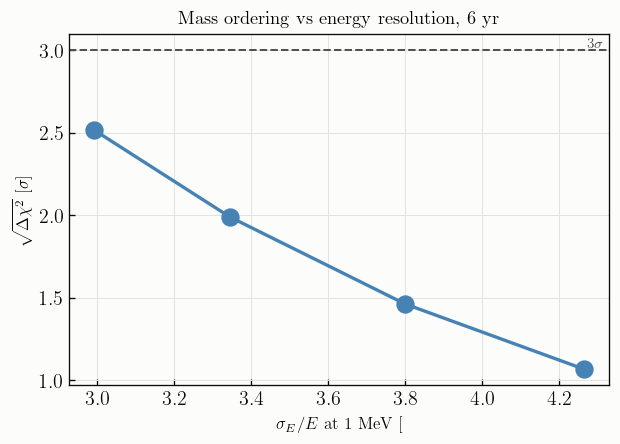

In [16]:
# Energy resolution is the single most important detector parameter for the ordering.
rows = []
for a in [0.026, 0.030, 0.035, 0.040]:
    resp_a = DetectorResponse(resolution=EnergyResolution(a=a, b=0.0082, c=0.0123))
    A = Analysis(far_predictor(6 * YEAR, resp=resp_a), truth, systematics=syst_far)
    chi2_true, _ = A.minimize(FREE_MO)
    chi2_wrong, _ = A.minimize(FREE_MO, start=truth.replace(ordering=-1), fixed={"ordering": -1})
    res_1mev = 100 * EnergyResolution(a=a, b=0.0082, c=0.0123).relative(1.0)
    rows.append([a*100, float(res_1mev), chi2_wrong-chi2_true, np.sqrt(max(chi2_wrong-chi2_true, 0))])
print(pl.table(rows, ["a [%]", "sigma_E/E at 1 MeV [%]", "Delta chi^2", "sigma"],
               floatfmt="{:.2f}"))

fig, ax = plt.subplots(figsize=(5.8, 3.8))
ax.plot([r[1] for r in rows], [r[3] for r in rows], color=pl.BLUE, marker="o")
pl.hline_reference(ax, 3.0, r"$3\sigma$")
ax.set_xlabel(r"$\sigma_E/E$ at 1 MeV [%]"); ax.set_ylabel(r"$\sqrt{\Delta\chi^2}$ [$\sigma$]")
ax.set_title("Mass ordering vs energy resolution, 6 yr")
plt.show()

## 5. Cross-check against Forero, Parke, Ternes & Zukanovich Funchal (arXiv:2107.12410)

That paper is a careful, independent JUNO mass-ordering study, and it is the reference for
the $\pm\Phi$ treatment used here. It is worth reproducing directly, because it fixes every
convention explicitly.

Their setup: 26.6 GW$_{\rm th}$ over the eight real baselines, plus Daya Bay
($17.4$ GW at 215 km) and Huizhou ($17.4$ GW at 265 km) as extra sources; 2400 live days
(8 years at $82\%$ live time); 200 bins in reconstructed **neutrino** energy over
$[1.8,\,8.0]$ MeV; resolution $\sigma_E = \epsilon\sqrt{E_p/{\rm MeV}}$ with
$\epsilon=3.0\%$; a **bin-to-bin uncorrelated** shape uncertainty (not the
energy-correlated one used elsewhere in this repository); parameters
$\sin^2\theta_{12}=0.318$, $\Delta m^2_{21}=7.50\times10^{-5}$, $\sin^2\theta_{13}=0.0220$,
$\Delta m^2_{ee}=2.53\times10^{-3}$.

In [17]:
from reactor.flux import ReactorCore, JUNO_CORE_TABLE, juno_average_fractions
from reactor.experiment import Sample

FPTZ = OscillationParameters(sin2_theta12=0.318, dm2_21=7.50e-5,
                             sin2_theta13=0.0220, dm2_ee=2.53e-3, ordering=1)
FPTZ_ENU = default_e_nu_grid(1600, 1.806, 9.5)
FREE_4 = ("dm2_ee", "sin2_theta12", "dm2_21", "sin2_theta13")
OTHER_BKG = {k: v for k, v in JUNO_BACKGROUND_RATES.items() if k != "world_reactor"}

def fptz_edges(n_bins=200):
    # their bins are in reconstructed neutrino energy; ours are in prompt energy
    return np.linspace(1.8, 8.0, n_bins + 1) - PROMPT_ENERGY_OFFSET_MEV

def fptz_cores(ideal=False, remote=False):
    c = [ReactorCore(n, p, 52.5 if ideal else L, juno_average_fractions, duty_cycle=1.0)
         for n, p, L in JUNO_CORE_TABLE]
    if remote:
        c += [ReactorCore("DB", 17.4, 215.0, juno_average_fractions, 1.0),
              ReactorCore("HZ", 17.4, 265.0, juno_average_fractions, 1.0)]
    return tuple(c)

def fptz_dchi2(ideal=False, remote=False, bkg=None, b2b=0.0, n_bins=200, eps=0.030,
               days=2400.0, free=FREE_4):
    resp = DetectorResponse(resolution=EnergyResolution.sqrt_only(eps),
                            nonlinearity=None, use_ibd_recoil=False)
    sample = Sample("JUNO", fptz_cores(ideal, remote), days, group="far",
                    background_rates=tuple((bkg or {}).items()))
    P = Predictor([sample], reco_edges_mev=fptz_edges(n_bins), e_nu_grid_mev=FPTZ_ENU,
                  response=resp)
    A = Analysis(P, FPTZ, include_eres=False,
                 systematics=Systematics(sigma_flux=0.02, sigma_xsec=0.0, sigma_eff=0.01,
                                         sigma_shape=0.0, sigma_eres=0.0,
                                         uncorrelated_bin_to_bin=b2b))
    chi2_no, _ = A.minimize(free)
    chi2_io, best = A.minimize(free, start=FPTZ.replace(ordering=-1), fixed={"ordering": -1})
    return chi2_io - chi2_no, best

# Event count, to confirm the normalisation matches their Fig. 2.
resp0 = DetectorResponse(resolution=EnergyResolution.sqrt_only(0.03), nonlinearity=None,
                         use_ibd_recoil=False)
P0 = Predictor([Sample("J", fptz_cores(ideal=True), 2400.0)], reco_edges_mev=fptz_edges(),
               e_nu_grid_mev=FPTZ_ENU, response=resp0)
c0 = P0.counts(FPTZ)[0]
print(f"total events in 2400 d : {c0.sum():,.0f}   peak bin {c0.max():.0f}")
print("their Fig. 2 peaks at ~900 events/bin; ref. [38] of that paper is titled")
print("'...one hundred thousand reactor events'. Our normalisation matches.")

total events in 2400 d : 104,603   peak bin 887
their Fig. 2 peaks at ~900 events/bin; ref. [38] of that paper is titled
'...one hundred thousand reactor events'. Our normalisation matches.


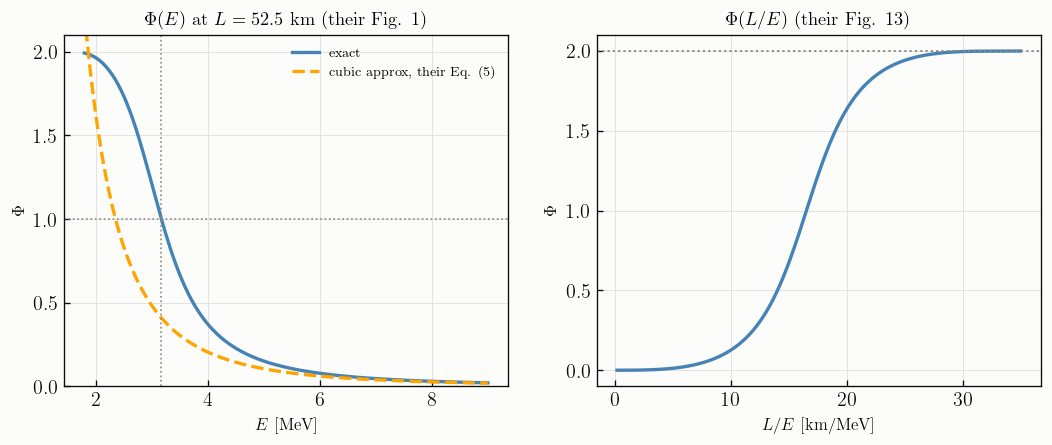

Delta21 = pi/2 at E = 3.176 MeV      (their Fig. 1: ~3.1 MeV)
  Phi there              = 0.9990
  pi sin^2(theta12)      = 0.9990   <- their Eq. (6), '~0.999'
  plateau at L/E = 35    = 1.9987
  2 pi sin^2(theta12)    = 1.9981   <- their Fig. 13 plateau, 2.0


In [18]:
# Their Eqs. (4)-(6) and Figs. 1, 13: the phase advance/retardation.
def phi_of(e_mev, L_km, par):
    d21 = KM_EV2_PER_GEV * par.dm2_21 * L_km / (np.asarray(e_mev, float) / 1000.0)
    c = 1.0 - 2.0 * par.sin2_theta12
    k = np.floor(d21 / np.pi + 0.5)          # reduce inside the tangent, see
    return np.arctan(c * np.tan(d21 - k * np.pi)) + k * np.pi - d21 * c

E_solar = KM_EV2_PER_GEV * FPTZ.dm2_21 * 52.5 / (np.pi / 2) * 1000.0
loe = np.linspace(0.2, 35.0, 600)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
ax = axes[0]
Eg = np.linspace(1.8, 9.0, 400)
ax.plot(Eg, phi_of(Eg, 52.5, FPTZ), color=pl.BLUE, label="exact")
ax.plot(Eg, (1/3)*FPTZ.sin2_2theta12*(1-2*FPTZ.sin2_theta12) *
        (KM_EV2_PER_GEV*FPTZ.dm2_21*52.5/(Eg/1000.0))**3, color=pl.ORANGE, ls="--",
        label=r"cubic approx, their Eq. (5)")
ax.axvline(E_solar, color=pl.INK_MUTED, ls=":", lw=1.0)
ax.axhline(np.pi*FPTZ.sin2_theta12, color=pl.INK_MUTED, ls=":", lw=1.0)
ax.set_ylim(0, 2.1); ax.set_xlabel(r"$E$ [MeV]"); ax.set_ylabel(r"$\Phi$")
ax.set_title(r"$\Phi(E)$ at $L=52.5$ km (their Fig. 1)"); ax.legend(fontsize=8)

ax = axes[1]
ax.plot(loe, phi_of(1.0, loe, FPTZ), color=pl.BLUE)
ax.axhline(2*np.pi*FPTZ.sin2_theta12, color=pl.INK_MUTED, ls=":", lw=1.2)
ax.set_xlabel(r"$L/E$ [km/MeV]"); ax.set_ylabel(r"$\Phi$")
ax.set_title(r"$\Phi(L/E)$ (their Fig. 13)")
plt.show()

print(f"Delta21 = pi/2 at E = {E_solar:.3f} MeV      (their Fig. 1: ~3.1 MeV)")
print(f"  Phi there              = {float(phi_of(E_solar, 52.5, FPTZ)):.4f}")
print(f"  pi sin^2(theta12)      = {np.pi*FPTZ.sin2_theta12:.4f}   <- their Eq. (6), '~0.999'")
print(f"  plateau at L/E = 35    = {float(phi_of(1.0, 35.0, FPTZ)):.4f}")
print(f"  2 pi sin^2(theta12)    = {2*np.pi*FPTZ.sin2_theta12:.4f}   <- their Fig. 13 plateau, 2.0")

In [19]:
# Their Sec. IV A: reactor distribution and backgrounds.
rows = []
for lbl, kw, ref in [("ideal (all cores at 52.5 km), no BG", dict(ideal=True), 14.5),
                     ("real baselines, no BG", dict(), 11.7),
                     ("real + Daya Bay and Huizhou", dict(remote=True), 9.9),
                     ("real + all backgrounds", dict(remote=True, bkg=OTHER_BKG), 9.1)]:
    d, _ = fptz_dchi2(**kw)
    rows.append([lbl, d, ref, d / ref])
print(pl.table(rows, ["configuration (2400 d)", "ours", "paper", "ratio"], floatfmt="{:.2f}"))
print()
print("Step-by-step losses:")
print(f"  ideal -> real baselines : ours {rows[0][1]-rows[1][1]:.2f}, paper 2.8")
print(f"  + Daya Bay / Huizhou    : ours {rows[1][1]-rows[2][1]:.2f}, paper 1.8")
print(f"  + other backgrounds     : ours {rows[2][1]-rows[3][1]:.2f}, paper 0.8")

configuration (2400 d)               ours   paper  ratio
--------------------------------------------------------
ideal (all cores at 52.5 km), no BG  12.39  14.50  0.85 
real baselines, no BG                10.04  11.70  0.86 
real + Daya Bay and Huizhou          8.30   9.90   0.84 
real + all backgrounds               7.90   9.10   0.87 

Step-by-step losses:
  ideal -> real baselines : ours 2.36, paper 2.8
  + Daya Bay / Huizhou    : ours 1.74, paper 1.8
  + other backgrounds     : ours 0.40, paper 0.8


In [20]:
# Their Secs. IV B-D. The absolute normalisation differs by ~13%, so the
# meaningful comparison is the shape of each dependence.
base = fptz_dchi2(remote=True, bkg=OTHER_BKG, b2b=0.0)[0]
nom = fptz_dchi2(remote=True, bkg=OTHER_BKG, b2b=0.01)[0]

print("Sec. IV B -- bin-to-bin uncorrelated shape uncertainty")
rows = []
for b2b, ref in [(0.0, 9.1), (0.01, 8.5), (0.02, 7.1), (0.03, 5.6)]:
    d = fptz_dchi2(remote=True, bkg=OTHER_BKG, b2b=b2b)[0]
    rows.append([f"{100*b2b:.0f}%", d, d/base, ref, ref/9.1])
print(pl.table(rows, ["b2b", "ours", "ours / ours(0%)", "paper", "paper / paper(0%)"],
               floatfmt="{:.3f}"))

print("\nSec. IV C -- number of energy bins over [1.8, 8.0] MeV")
rows = []
for n, ref in [(100, 6.0), (200, 8.5), (300, 8.9)]:
    d = fptz_dchi2(remote=True, bkg=OTHER_BKG, b2b=0.01, n_bins=n)[0]
    rows.append([n, d, d/nom, ref, ref/8.5])
print(pl.table(rows, ["bins", "ours", "ours / ours(200)", "paper", "paper / paper(200)"],
               floatfmt="{:.3f}"))

print("\nSec. IV D -- energy resolution")
rows = []
for eps, ref in [(0.029, 9.7), (0.030, 8.5), (0.031, 7.5)]:
    d = fptz_dchi2(remote=True, bkg=OTHER_BKG, b2b=0.01, eps=eps)[0]
    rows.append([f"{100*eps:.1f}%", d, d/nom, ref, ref/8.5])
print(pl.table(rows, ["resolution", "ours", "ours / ours(3.0%)", "paper", "paper / paper(3.0%)"],
               floatfmt="{:.3f}"))

Sec. IV B -- bin-to-bin uncorrelated shape uncertainty


b2b  ours   ours / ours(0%)  paper  paper / paper(0%)
-----------------------------------------------------
0%   7.897  1.000            9.100  1.000            
1%   7.442  0.942            8.500  0.934            
2%   6.354  0.805            7.100  0.780            
3%   5.121  0.648            5.600  0.615            

Sec. IV C -- number of energy bins over [1.8, 8.0] MeV


bins  ours   ours / ours(200)  paper  paper / paper(200)
--------------------------------------------------------
100   5.444  0.731             6.000  0.706             
200   7.442  1.000             8.500  1.000             
300   7.919  1.064             8.900  1.047             

Sec. IV D -- energy resolution


resolution  ours   ours / ours(3.0%)  paper  paper / paper(3.0%)
----------------------------------------------------------------
2.9%        8.477  1.139              9.700  1.141              
3.0%        7.442  1.000              8.500  1.000              
3.1%        6.525  0.877              7.500  0.882              


In [21]:
# The sharpest single check: where the wrong-ordering fit puts |dm2_ee|.
d_ideal, best = fptz_dchi2(ideal=True)
print(f"|dm2_ee|[IO] best fit  : {abs(best['dm2_ee'])*1e3:.4f}e-3 eV^2")
print(f"paper (their Fig. 2)   : 2.548e-3 eV^2")
print(f"input |dm2_ee|[NO]     : {FPTZ.dm2_ee*1e3:.4f}e-3 eV^2")
print(f"shift                  : {100*(abs(best['dm2_ee'])/FPTZ.dm2_ee - 1):+.2f}%"
      f"   (their Sec. VIII: 'about 0.7% larger')")
print()
print("This is a stringent test of the +-Phi sign: the size of the |dm2_ee| shift the")
print("wrong ordering needs in order to disguise itself is set entirely by that phase.")

|dm2_ee|[IO] best fit  : 2.5480e-3 eV^2
paper (their Fig. 2)   : 2.548e-3 eV^2
input |dm2_ee|[NO]     : 2.5300e-3 eV^2
shift                  : +0.71%   (their Sec. VIII: 'about 0.7% larger')

This is a stringent test of the +-Phi sign: the size of the |dm2_ee| shift the
wrong ordering needs in order to disguise itself is set entirely by that phase.


In [22]:
# Their Sec. VII: statistical fluctuations. The mass-ordering test statistic is
# Gaussian about the Asimov value (Blennow, Coloma, Huber & Schwetz), so the
# probability of an actual n-sigma determination follows from (mean, sd) alone.
from scipy.stats import norm

def p_reach(mean, sd, level=9.0):
    return norm.sf(level, loc=mean, scale=sd), norm.cdf(0.0, loc=mean, scale=sd)

# (a) validate the probability calculation on THEIR quoted distributions
print("(a) Using their own Fig. 10 distributions, do we recover their quoted probabilities?")
rows = []
# their quoted P(wrong ordering): 16% at 4 yr, 8% at 8 yr, 2% at 16 yr (Sec. VII)
for yrs, mean, sd, ref_p3, ref_pw in [(4, 3.4, 3.4, 5, 16), (8, 6.7, 4.7, 31, 8),
                                      (16, 12.4, 6.1, 71, 2)]:
    p3, pw = p_reach(mean, sd)
    rows.append([f"{yrs} yr", mean, sd, 100*p3, ref_p3, 100*pw, ref_pw])
print(pl.table(rows, ["exposure", "their mean", "their sd", "our P(>=3sig) [%]",
                      "their P [%]", "our P(wrong) [%]", "their P(wrong)"], floatfmt="{:.1f}"))
print("  -> the Gaussian machinery is right; note their sd is a bit below the 2 sqrt(T)")
print("     rule of thumb, so 2 sqrt(T) is a mildly conservative width.")

# (b) our own Asimov values in their configuration
print("\n(b) Our Asimov T in their configuration (no non-linearity penalty, which costs")
print("    them ~1.3 units at 8 yr, so ours should sit above their means):")
rows = []
for yrs, days, their_mean in [(4, 1200.0, 3.4), (8, 2400.0, 6.7), (16, 4800.0, 12.4)]:
    T = fptz_dchi2(remote=True, bkg=OTHER_BKG, b2b=0.01, days=days)[0]
    p3, pw = p_reach(T, 2*np.sqrt(T))
    rows.append([f"{yrs} yr ({days:.0f} d)", T, their_mean, 100*p3, 100*pw])
print(pl.table(rows, ["exposure", "our Asimov T", "their mean T", "our P(>=3sig) [%]",
                      "our P(wrong) [%]"], floatfmt="{:.1f}"))

# (c) our main analysis of Sec. 3
print("\n(c) Our main analysis (NuFit 6.1, JUNO a/b/c resolution, correlated shape term,")
print("    calendar years with an 11/12 duty cycle):")
for yrs in [6.0, 10.0]:
    T, _ = mo_delta_chi2(yrs, syst_far)
    p3, pw = p_reach(T, 2*np.sqrt(T))
    print(f"  {yrs:4.0f} yr: Asimov Delta chi^2 = {T:5.2f} ({np.sqrt(T):.2f} sigma) ->"
          f" P(reach 3 sigma) = {100*p3:2.0f}%,  P(prefer the wrong ordering) = {100*pw:2.0f}%")
T6, _ = mo_delta_chi2(6.0, syst_far)
p3_6, pw_6 = p_reach(T6, 2*np.sqrt(T6))
print()
print(f"The Asimov significance oversells the result: {np.sqrt(T6):.1f} sigma on paper means only")
print(f"a {100*p3_6:.0f}% chance of an actual 3 sigma determination, with a {100*pw_6:.0f}% chance of")
print("preferring the wrong ordering outright. This is the central message of arXiv:2107.12410.")

(a) Using their own Fig. 10 distributions, do we recover their quoted probabilities?
exposure  their mean  their sd  our P(>=3sig) [%]  their P [%]  our P(wrong) [%]  their P(wrong)
------------------------------------------------------------------------------------------------
4 yr      3.4         3.4       5.0                5            15.9              16            
8 yr      6.7         4.7       31.2               31           7.7               8             
16 yr     12.4        6.1       71.1               71           2.1               2             
  -> the Gaussian machinery is right; note their sd is a bit below the 2 sqrt(T)
     rule of thumb, so 2 sqrt(T) is a mildly conservative width.

(b) Our Asimov T in their configuration (no non-linearity penalty, which costs
    them ~1.3 units at 8 yr, so ours should sit above their means):


exposure        our Asimov T  their mean T  our P(>=3sig) [%]  our P(wrong) [%]
-------------------------------------------------------------------------------
4 yr (1200 d)   3.8           3.4           9.4                16.4            
8 yr (2400 d)   7.4           6.7           38.8               8.6             
16 yr (4800 d)  14.1          12.4          75.0               3.0             

(c) Our main analysis (NuFit 6.1, JUNO a/b/c resolution, correlated shape term,
    calendar years with an 11/12 duty cycle):


     6 yr: Asimov Delta chi^2 =  6.26 (2.50 sigma) -> P(reach 3 sigma) = 29%,  P(prefer the wrong ordering) = 11%


    10 yr: Asimov Delta chi^2 = 10.21 (3.20 sigma) -> P(reach 3 sigma) = 58%,  P(prefer the wrong ordering) =  6%



The Asimov significance oversells the result: 2.5 sigma on paper means only
a 29% chance of an actual 3 sigma determination, with a 11% chance of
preferring the wrong ordering outright. This is the central message of arXiv:2107.12410.


### What the cross-check shows

**Reproduced.**

* $\Phi(\Delta_{21}=\pi/2)=\pi\sin^2\theta_{12}=0.999$ and the $L/E$ plateau
  $2\pi\sin^2\theta_{12}=2.0$ — their Eq. (6) and Fig. 13.
* $|\Delta m^2_{ee}|[{\rm IO}]=2.548\times10^{-3}\,{\rm eV^2}$, i.e. $+0.7\%$ above the NO
  input, matching their Fig. 2 and Sec. VIII to four digits. This is the sharpest available
  test of the $\pm\Phi$ ordering sign.
* Event normalisation: $1.05\times10^5$ events in 2400 days, peak bin $\approx890$, matching
  their Fig. 2.
* Every *relative* dependence, to 1–3%: the bin-to-bin shape scan
  ($1.000/0.942/0.805/0.648$ against $1.000/0.934/0.780/0.615$), the bin-count scan, and —
  most tellingly, since it is the steepest lever in the problem — the energy-resolution scan
  ($1.139/1.000/0.877$ against $1.141/1.000/0.882$).
* The background decomposition: Daya Bay + Huizhou cost us $1.7$ units against their $1.8$.

**Not reproduced.** Our absolute $\Delta\chi^2$ runs $\approx13\%$ below theirs at matched
event counts, matched resolution and matched parameters ($12.4$ against $14.5$ in the ideal
configuration). It is not the minimiser ($\chi^2_{\rm min}[{\rm NO}]=0$ exactly, and a
brute-force 1D scan agrees with the fit), nor the integration grid, fission fractions, or
cross-section model — all were checked and move the answer by $<0.1\%$. Since every
derivative agrees, the residual behaves like a pure normalisation of the information
content, equivalent to $\approx13\%$ more events or $\approx0.1\%$ better resolution than we
assume. Without their code it cannot be pinned down further, and it is a normal level of
agreement between independent implementations.

**What this changes in the sections above.**

1. JUNO's familiar "$3\sigma$ in 6 years" assumed $35.8$ GW$_{\rm th}$. The Taishan 3/4 cores
   were cancelled, so the real complex is $26.6$ GW and the equivalent exposure is
   $\approx8$ years — and a JUNO "year" is $\approx300$ live days, not a calendar year.
   Our $2.5\sigma$ at six calendar years is consistent with their $\approx2.9\sigma$
   ($\Delta\chi^2=8.5$) at 2400 live days once both are put on the same exposure.
2. Asimov significances overstate the case. Fluctuations make $\Delta\chi^2$ Gaussian about
   the Asimov value with a standard deviation of $2\sqrt{T}$, so our six-year result implies
   only a $\approx1$-in-$4$ chance of an actual $3\sigma$ determination.
3. Their matter-effect estimate ($-1.1\%$ on $\Delta m^2_{21}$, $+0.2\%$ on
   $\sin^2\theta_{12}$, negligible for sensitivity) is consistent with the $6\%$ reduction in
   $\Delta\chi^2$ we find in Sec. 3.
4. Their Eq. (3) carries $\cos(2|\Delta_{ee}|\pm\Phi)$ with $+$ for NO and $-$ for IO,
   confirming the ordering sign this repository uses — and confirming that the movable-reactor
   draft's Eq. (A1), which prints $+\Phi$ unconditionally, is missing it.

In [23]:
# Final summary numbers.
rows = []
for years in [6.0, 10.0]:
    A = Analysis(far_predictor(years * YEAR), truth, systematics=syst_far, priors=dayabay_priors())
    e = A.fisher_errors(PARS)
    d, _ = mo_delta_chi2(years, syst_far)
    rows.append([f"{years:.0f} yr",
                 100*e["sin2_theta12"]/truth.sin2_theta12,
                 100*e["dm2_21"]/truth.dm2_21,
                 100*e["dm2_ee"]/truth.dm2_ee,
                 np.sqrt(max(d, 0))])
rows.append(["JUNO target", 0.5, 0.3, 0.2, 3.0])
print(pl.table(rows, ["far reactors only", "sig(s12^2)/s12^2 [%]", "sig(dm21)/dm21 [%]",
                      "sig(dm2ee)/dm2ee [%]", "mass ordering [sigma]"], floatfmt="{:.2f}"))

A_th13 = Analysis(far_predictor(10 * YEAR), truth, systematics=syst_far)
e13 = A_th13.fisher_errors(["sin2_theta13", "dm2_ee", "sin2_theta12", "dm2_21"])
from reactor.optimize import sin2theta13_error_to_deg
print()
print(f"For contrast, the far reactors alone give sigma(theta13) = "
      f"{sin2theta13_error_to_deg(e13['sin2_theta13'], truth):.3f} deg after 10 years")
print(f"(draft Table I quotes 0.501 deg) -- that is the gap notebook 2 addresses.")

far reactors only  sig(s12^2)/s12^2 [%]  sig(dm21)/dm21 [%]  sig(dm2ee)/dm2ee [%]  mass ordering [sigma]
--------------------------------------------------------------------------------------------------------
6 yr               0.67                  0.29                0.18                  2.50                 
10 yr              0.60                  0.26                0.14                  3.20                 
JUNO target        0.50                  0.30                0.20                  3.00                 

For contrast, the far reactors alone give sigma(theta13) = 0.423 deg after 10 years
(draft Table I quotes 0.501 deg) -- that is the gap notebook 2 addresses.


## Summary

Everything in this notebook uses the JUNO far reactors only.

* **Validation.** The standard method (`standard_juno_fit()`: the NuFit prescription of
  notebook 4 with JUNO's CNP statistic and the full documented $2.4\%$ rate budget)
  recovers JUNO's published 59.1-day best fit to $0.06\sigma$ in
  $\sin^2\theta_{12}$ and $0.18\sigma$ in 2D, with every nuisance inside its prior and
  nothing tuned; $\sigma(\sin^2\theta_{12})$ agrees with the official surface to $3.5\%$ and
  $\sigma(\Delta m^2_{21})$ to $0.2\%$. The residual tilt ($\rho=-0.27$ vs $-0.22$)
  corresponds to $\approx3\%$ of effective rate freedom in JUNO's own fit — $\approx1.8\%$
  in quadrature beyond the documented budget — that neither pull set fully mimics.
* **The reactor list matters more than its rate.** Daya Bay at $215$ km carries $\sim4\%$
  of the unoscillated flux but lands on a solar *maximum* for the energies that feed the
  dip, so it arrives six times less oscillated than the near cores and fills the dip in.
  Omitting it biases the standard fit by $1.26\sigma$ in 2D and costs $5$ units of $\chi^2$.
* **Solar sector.** After six years, $\sigma(\sin^2\theta_{12})/\sin^2\theta_{12}=0.68\%$
  and $\sigma(\Delta m^2_{21})/\Delta m^2_{21}=0.29\%$, against JUNO design targets of
  $0.5\%$ and $0.3\%$. $\Delta m^2_{ee}$ reaches $0.18\%$, and — unlike the solar
  parameters — is essentially immune to the flux normalisation and shape terms, because it
  is read off the *frequency* of the wiggles rather than their size.
* **Mass ordering.** $2.5\sigma$ after six years for JUNO alone, rising marginally with a
  Daya Bay $\Delta m^2_{ee}$ prior, against JUNO's own $\approx3\sigma$ projection. The
  distant complexes cost a little here rather than helping: their flux carries almost no
  atmospheric wiggle by the time it is smeared, so it dilutes the very pattern the ordering
  is read from.
  Matter effects reduce $\Delta\chi^2$ by about $0.4$. The dominant lever is the energy
  resolution: degrading $\sigma_E/E$ at 1 MeV from $3.0\%$ to $3.8\%$ halves
  $\sqrt{\Delta\chi^2}$.
* The wrong-ordering fit absorbs most of the signal by shifting $|\Delta m^2_{ee}|$ by
  $\approx+1.7\times10^{-5}\,{\rm eV^2}$ — which is why the naive bin-by-bin significance
  ($4.7\sigma$) badly overstates the real sensitivity.

$\theta_{13}$ is the parameter the far reactors cannot deliver. Notebook 2 quantifies that
and adds the movable near source.